
Parsed 45 files from 15 mice.
group
Agg            15
maladaptive    15
nonAgg         15

Saved:
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\attack_vs_submission.png
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\attack_vs_submission.pdf
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\bout_counts.csv


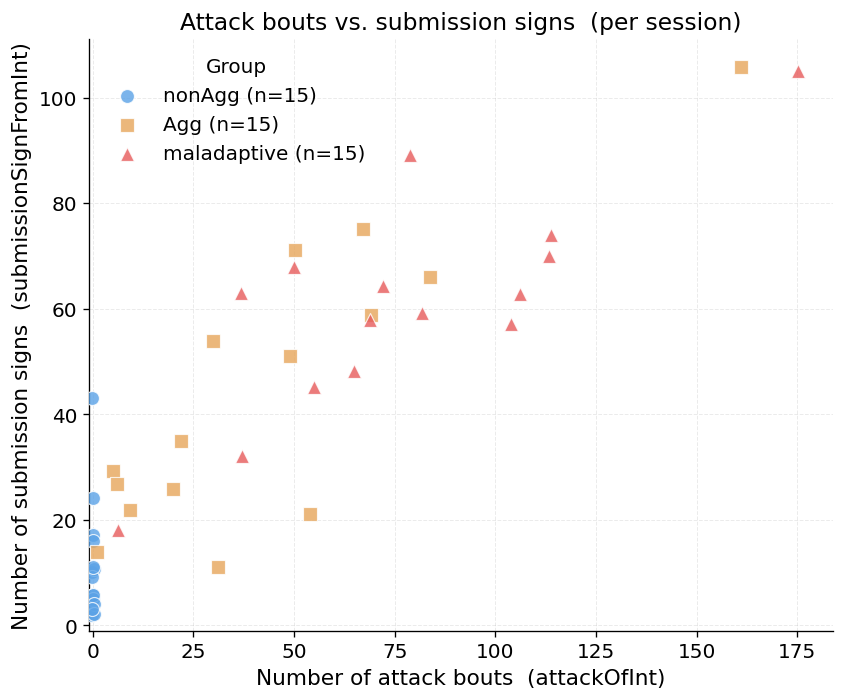

In [3]:
"""
Plot attack bouts (x) vs. submission signs (y) across the annotation dataset.

Each .annot file is a Bento annotation export containing two behaviors:
    attackOfInt
    submissionSignFromInt
A "bout" / "sign" = one (Start, Stop, Duration) row under that behavior header.

The script walks every mouse folder under DT_FOLDER, decides each mouse's group
from its ID, counts bouts in every .annot file, and produces a coloured scatter.

Run:  python plot_attack_vs_submission.py
Outputs (written to OUT_DIR):
    attack_vs_submission.png / .pdf   the figure
    bout_counts.csv                   the raw per-file counts behind the plot
"""

import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------------------------------------------------------- #
# CONFIG  — edit these
# ----------------------------------------------------------------------------- #
DT_FOLDER = Path(r"A:\rawData\compressedVideos_AVI\trainingSessions_DLC"
                 r"\fig1_trainingSessions_annotationsNoemie_non_agg_mal")

OUT_DIR = Path.cwd()            # where the figure + csv are saved

# "session" -> one point per .annot file (each mouse contributes ~3 points)
# "mouse"   -> one point per mouse (counts summed across that mouse's files)
MODE = "session"

JITTER = 0.25                   # tiny scatter so identical integer counts don't fully overlap (0 to disable)
LABEL_POINTS = False           # annotate each point with its mouse ID (gets busy with many points)

BEHAVIORS = {
    "attack":     "attackOfInt",            # -> x axis
    "submission": "submissionSignFromInt",  # -> y axis
}

# Mouse groups
GROUPS = {
    "Agg": ["975826", "975827", "975833", "978772", "978774", "988590",
            "997838", "1010820", "1010823", "1010826", "1029741"],
    "nonAgg": ["975830", "978775", "1010819", "997839", "997840", "997841",
               "1029736", "1029739", "1032216"],
    "maladaptive": ["978513", "978527", "978528", "1010832", "1013590",
                    "1034805", "1034814"],
}

GROUP_COLORS  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
GROUP_MARKERS = {"nonAgg": "o",       "Agg": "s",       "maladaptive": "^"}
GROUP_ORDER   = ["nonAgg", "Agg", "maladaptive"]

# ----------------------------------------------------------------------------- #
# Parsing
# ----------------------------------------------------------------------------- #
ID_TO_GROUP = {mid: g for g, ids in GROUPS.items() for mid in ids}
# longest IDs first so a 7-digit ID is preferred over any shorter coincidental match
_ID_PATTERNS = [(mid, re.compile(rf"(?<!\d){re.escape(mid)}(?!\d)"))
                for mid in sorted(ID_TO_GROUP, key=len, reverse=True)]

_ROW_RE = re.compile(r"^\s*\d+\s+\d+\s+\d+\s*$")  # a Start/Stop/Duration row


def mouse_id_from(text: str):
    """Return the known mouse ID found in a path/name, or None."""
    for mid, pat in _ID_PATTERNS:
        if pat.search(text):
            return mid
    return None


def count_bouts(annot_path: Path) -> dict:
    """Count rows under each behaviour header in one .annot file."""
    counts = {name: 0 for name in BEHAVIORS.values()}
    current = None
    with open(annot_path, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            stripped = line.strip()
            if stripped.startswith(">"):
                current = stripped[1:].strip()
            elif current in counts and _ROW_RE.match(line):
                counts[current] += 1
    return counts


def collect() -> pd.DataFrame:
    """Walk DT_FOLDER and build a per-file table of bout counts."""
    if not DT_FOLDER.exists():
        sys.exit(f"DT_FOLDER does not exist:\n  {DT_FOLDER}")

    rows = []
    annot_files = sorted(DT_FOLDER.rglob("*.annot"))
    if not annot_files:
        sys.exit(f"No .annot files found under:\n  {DT_FOLDER}")

    for f in annot_files:
        mid = mouse_id_from(str(f))
        if mid is None:
            print(f"  [skip] no known mouse ID in path: {f}")
            continue
        c = count_bouts(f)
        rows.append({
            "mouse_id": mid,
            "group": ID_TO_GROUP[mid],
            "file": f.name,
            "attack_bouts": c[BEHAVIORS["attack"]],
            "submission_signs": c[BEHAVIORS["submission"]],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        sys.exit("Found .annot files but none matched a known mouse ID.")

    # sanity check: how many files per mouse?
    per_mouse = df.groupby("mouse_id").size()
    odd = per_mouse[per_mouse != 3]
    if len(odd):
        print("  [note] mice without exactly 3 .annot files:")
        for m, n in odd.items():
            print(f"         {m} ({ID_TO_GROUP[m]}): {n} file(s)")
    return df


# ----------------------------------------------------------------------------- #
# Plotting
# ----------------------------------------------------------------------------- #
def style():
    mpl.rcParams.update({
        "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13,
        "axes.spines.top": False, "axes.spines.right": False,
        "figure.dpi": 120, "savefig.dpi": 300,
    })


def make_plot(df: pd.DataFrame, mode: str):
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(7.2, 6))

    for g in GROUP_ORDER:
        sub = df[df["group"] == g]
        if sub.empty:
            continue
        x = sub["attack_bouts"].to_numpy(float)
        y = sub["submission_signs"].to_numpy(float)
        if JITTER:
            x = x + rng.uniform(-JITTER, JITTER, x.shape)
            y = y + rng.uniform(-JITTER, JITTER, y.shape)
        ax.scatter(x, y, s=70, c=GROUP_COLORS[g], marker=GROUP_MARKERS[g], alpha=0.8,
                   edgecolors="white", linewidths=0.7,
                   label=f"{g} (n={len(sub)})", zorder=3)
        if LABEL_POINTS:
            for xi, yi, mid in zip(x, y, sub["mouse_id"]):
                ax.annotate(mid, (xi, yi), textcoords="offset points",
                            xytext=(4, 4), fontsize=7, color="0.3")

    unit = "per session" if mode == "session" else "per mouse"
    ax.set_xlabel(f"Number of attack bouts  (attackOfInt)")
    ax.set_ylabel(f"Number of submission signs  (submissionSignFromInt)")
    ax.set_title(f"Attack bouts vs. submission signs  ({unit})")
    ax.set_xlim(left=-1)
    ax.set_ylim(bottom=-1)
    ax.legend(title="Group", frameon=False, loc="best")
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
    fig.tight_layout()
    return fig


# ----------------------------------------------------------------------------- #
# Main
# ----------------------------------------------------------------------------- #
def main():
    style()
    df = collect()

    if MODE == "mouse":
        plot_df = (df.groupby(["mouse_id", "group"], as_index=False)
                     [["attack_bouts", "submission_signs"]].sum())
    else:
        plot_df = df

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = OUT_DIR / "bout_counts.csv"
    df.sort_values(["group", "mouse_id", "file"]).to_csv(csv_path, index=False)

    fig = make_plot(plot_df, MODE)
    png = OUT_DIR / "attack_vs_submission.png"
    pdf = OUT_DIR / "attack_vs_submission.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    print(f"\nParsed {len(df)} files from {df['mouse_id'].nunique()} mice.")
    print(df.groupby("group").size().to_string())
    print(f"\nSaved:\n  {png}\n  {pdf}\n  {csv_path}")
    plt.show()


if __name__ == "__main__":
    main()


Parsed 45 sessions from 15 mice.
Plotted 35 points (session).
Dropped 10 later maladaptive session(s); kept first per mouse.
group
Agg            15
maladaptive     5
nonAgg         15

Saved:
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\attack_vs_submission.png
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\attack_vs_submission.pdf
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\features_per_file.csv
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\plotted_points.csv


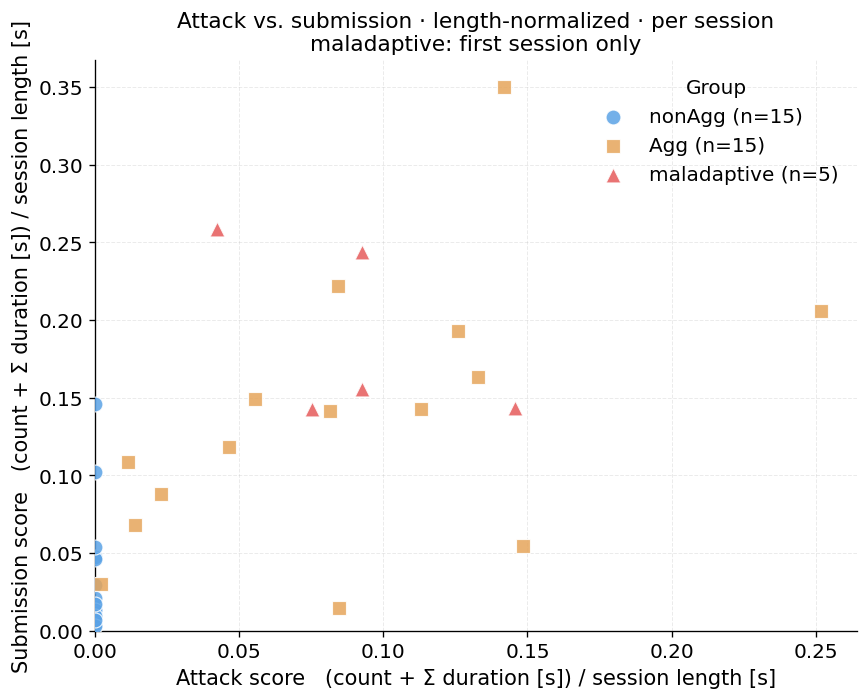

In [5]:
"""
Attack vs. submission scatter, where each axis is a COMBINED, length-normalized
score per behaviour:

    score = (number of bouts + total duration of bouts [s]) / session length [s]

    x = attack score      (attackOfInt)
    y = submission score  (submissionSignFromInt)

Counts and durations are read from each Bento .annot file; the session length
is taken from the header (Annotation stop time - Annotation start time, in
seconds) so sessions of slightly different length are comparable.

Sampling:
  * Agg / nonAgg            -> every session is a point.
  * maladaptive             -> only the FIRST session of each mouse (smallest
                              day number; days differ across mice, so "first"
                              is defined per mouse by the smallest day).

Run:  python plot_attack_vs_submission.py
Outputs (in OUT_DIR):
    attack_vs_submission.png / .pdf
    features_per_file.csv   every file: raw counts, durations, scores, used flag
    plotted_points.csv      exactly the points drawn (per session or per mouse)
"""

import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------------------------------------------------------- #
# CONFIG  — edit these
# ----------------------------------------------------------------------------- #
DT_FOLDER = Path(r"A:\rawData\compressedVideos_AVI\trainingSessions_DLC"
                 r"\fig1_trainingSessions_annotationsNoemie_non_agg_mal")

OUT_DIR = Path.cwd()

# "session" -> one point per .annot file
# "mouse"   -> one point per mouse (raw counts/durations/lengths pooled across
#              that mouse's used sessions, then the score recomputed)
MODE = "session"

MALADAPTIVE_FIRST_SESSION_ONLY = True   # keep only each maladaptive mouse's earliest-day session
JITTER = 0.0          # in score units; usually unnecessary (scores are continuous)
LABEL_POINTS = False  # annotate each point with its mouse ID

BEHAVIORS = {"attack": "attackOfInt", "submission": "submissionSignFromInt"}

# Mouse groups
GROUPS = {
    "Agg": ["975826", "975827", "975833", "978772", "978774", "988590",
            "997838", "1010820", "1010823", "1010826", "1029741"],
    "nonAgg": ["975830", "978775", "1010819", "997839", "997840", "997841",
               "1029736", "1029739", "1032216"],
    "maladaptive": ["978513", "978527", "978528", "1010832", "1013590",
                    "1034805", "1034814"],
}

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o",       "Agg": "s",       "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]

# ----------------------------------------------------------------------------- #
# Parsing
# ----------------------------------------------------------------------------- #
ID_TO_GROUP = {mid: g for g, ids in GROUPS.items() for mid in ids}
_ID_PATTERNS = [(mid, re.compile(rf"(?<!\d){re.escape(mid)}(?!\d)"))
                for mid in sorted(ID_TO_GROUP, key=len, reverse=True)]

_ROW_RE   = re.compile(r"^\s*(\d+)\s+(\d+)\s+(\d+)\s*$")  # Start Stop Duration (frames)
_VIDEO_RE = re.compile(r"mouse(\d+)_Day(\d+)")            # mouse + day, like filtered_results
_DAY_RE   = re.compile(r"[Dd]ay(\d+)")                    # fallback day from filename


def mouse_id_from(text: str):
    for mid, pat in _ID_PATTERNS:
        if pat.search(text):
            return mid
    return None


def parse_annot(path: Path) -> dict:
    """Single pass: header length + per-behaviour bout count and summed duration."""
    start = stop = framerate = None
    video = None
    counts = {name: 0 for name in BEHAVIORS.values()}
    dur_frames = {name: 0 for name in BEHAVIORS.values()}
    current = None
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            s = line.strip()
            if s.startswith("Annotation start time:"):
                start = float(s.split(":", 1)[1])
            elif s.startswith("Annotation stop time:"):
                stop = float(s.split(":", 1)[1])
            elif s.startswith("Annotation framerate:"):
                framerate = float(s.split(":", 1)[1])
            elif line.lower().startswith("movie file"):
                rest = line.split(":", 1)[1].strip()
                video = os.path.splitext(re.split(r"[\\/]", rest)[-1])[0]
            elif s.startswith(">"):
                current = s[1:].strip()
            else:
                m = _ROW_RE.match(line)
                if current in counts and m:
                    counts[current] += 1
                    dur_frames[current] += int(m.group(3))
    return {"video": video, "start": start, "stop": stop,
            "framerate": framerate, "counts": counts, "dur_frames": dur_frames}


def mouse_day_from(path: Path, video):
    """(mouse_id, day) from the movie 'video' name; fall back to the filename."""
    if video:
        m = _VIDEO_RE.search(video)
        if m:
            return m.group(1), int(m.group(2))
    stem = path.stem
    md = _DAY_RE.search(stem)
    mid = mouse_id_from(stem) or mouse_id_from(str(path))
    return mid, (int(md.group(1)) if md else None)


def collect():
    if not DT_FOLDER.exists():
        sys.exit(f"DT_FOLDER does not exist:\n  {DT_FOLDER}")
    files = sorted(DT_FOLDER.rglob("*.annot"))
    if not files:
        sys.exit(f"No .annot files found under:\n  {DT_FOLDER}")

    rows, skipped = [], []
    for f in files:
        info = parse_annot(f)
        mid, day = mouse_day_from(f, info["video"])
        if mid is None or mid not in ID_TO_GROUP:
            skipped.append({"file": f.name, "reason": "no_known_mouse_id"}); continue
        if day is None:
            skipped.append({"file": f.name, "reason": "no_day"}); continue
        if info["start"] is None or info["stop"] is None:
            skipped.append({"file": f.name, "reason": "no_session_length"}); continue

        fr = info["framerate"] or 50.0
        len_sec = info["stop"] - info["start"]
        att, sub = BEHAVIORS["attack"], BEHAVIORS["submission"]
        rows.append({
            "mouse_id": mid, "group": ID_TO_GROUP[mid], "file": f.name,
            "day": day, "video": info["video"], "len_sec": len_sec,
            "n_attack": info["counts"][att],
            "n_sub":    info["counts"][sub],
            "attack_dur_sec": info["dur_frames"][att] / fr,
            "sub_dur_sec":    info["dur_frames"][sub] / fr,
        })

    df = pd.DataFrame(rows)
    skipped_df = pd.DataFrame(skipped)
    if df.empty:
        if not skipped_df.empty:
            print(skipped_df.to_string(index=False))
        sys.exit("No .annot files mapped to a group with a usable length.")

    df = df.sort_values(["group", "mouse_id", "day"]).reset_index(drop=True)

    # keep only the earliest-day session for maladaptive mice
    df["used_in_plot"] = True
    if MALADAPTIVE_FIRST_SESSION_ONLY:
        is_mal = df["group"] == "maladaptive"
        keep = df[is_mal].sort_values("day").groupby("mouse_id").head(1).index
        drop = df.index[is_mal].difference(keep)
        df.loc[drop, "used_in_plot"] = False

    return df, skipped_df


def add_scores(d: pd.DataFrame) -> pd.DataFrame:
    """score = (count + total duration[s]) / length[s], plus its components."""
    d = d.copy()
    d["attack_score"]     = (d["n_attack"] + d["attack_dur_sec"]) / d["len_sec"]
    d["sub_score"]        = (d["n_sub"]    + d["sub_dur_sec"])     / d["len_sec"]
    d["attack_rate_per_s"] = d["n_attack"] / d["len_sec"]
    d["attack_time_frac"]  = d["attack_dur_sec"] / d["len_sec"]
    d["sub_rate_per_s"]    = d["n_sub"] / d["len_sec"]
    d["sub_time_frac"]     = d["sub_dur_sec"] / d["len_sec"]
    return d


# ----------------------------------------------------------------------------- #
# Plotting
# ----------------------------------------------------------------------------- #
def style():
    mpl.rcParams.update({
        "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12.5,
        "axes.spines.top": False, "axes.spines.right": False,
        "figure.dpi": 120, "savefig.dpi": 300,
    })


def make_plot(plot_df: pd.DataFrame, mode: str):
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(7.4, 6))
    for g in group_order:
        sub = plot_df[plot_df["group"] == g]
        if sub.empty:
            continue
        x = sub["attack_score"].to_numpy(float)
        y = sub["sub_score"].to_numpy(float)
        if JITTER:
            x = x + rng.uniform(-JITTER, JITTER, x.shape)
            y = y + rng.uniform(-JITTER, JITTER, y.shape)
        ax.scatter(x, y, s=80, c=group_colors[g], marker=group_markers[g], alpha=0.85,
                   edgecolors="white", linewidths=0.7,
                   label=f"{g} (n={len(sub)})", zorder=3)
        if LABEL_POINTS:
            for xi, yi, mid in zip(x, y, sub["mouse_id"]):
                ax.annotate(mid, (xi, yi), textcoords="offset points",
                            xytext=(4, 4), fontsize=7, color="0.3")

    unit = "per session" if mode == "session" else "per mouse (pooled)"
    ax.set_xlabel("Attack score   (count + Σ duration [s]) / session length [s]")
    ax.set_ylabel("Submission score   (count + Σ duration [s]) / session length [s]")
    ax.set_title(f"Attack vs. submission · length-normalized · {unit}\n"
                 "maladaptive: first session only", fontsize=13)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.margins(0.08)
    ax.legend(title="Group", frameon=False, loc="best")
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
    fig.tight_layout()
    return fig


# ----------------------------------------------------------------------------- #
# Main
# ----------------------------------------------------------------------------- #
def main():
    style()
    df, skipped_df = collect()

    used = df[df["used_in_plot"]].copy()
    if MODE == "mouse":
        plot_df = (used.groupby(["mouse_id", "group"], as_index=False)
                       .agg(len_sec=("len_sec", "sum"),
                            n_attack=("n_attack", "sum"), n_sub=("n_sub", "sum"),
                            attack_dur_sec=("attack_dur_sec", "sum"),
                            sub_dur_sec=("sub_dur_sec", "sum")))
    else:
        plot_df = used
    plot_df = add_scores(plot_df)

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    add_scores(df).sort_values(["group", "mouse_id", "day"]).to_csv(
        OUT_DIR / "features_per_file.csv", index=False)
    plot_df.sort_values(["group", "mouse_id"]).to_csv(
        OUT_DIR / "plotted_points.csv", index=False)
    if not skipped_df.empty:
        skipped_df.to_csv(OUT_DIR / "skipped.csv", index=False)

    fig = make_plot(plot_df, MODE)
    png = OUT_DIR / "attack_vs_submission.png"
    pdf = OUT_DIR / "attack_vs_submission.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    n_dropped = int((~df["used_in_plot"]).sum())
    print(f"\nParsed {len(df)} sessions from {df['mouse_id'].nunique()} mice.")
    print(f"Plotted {len(plot_df)} points ({MODE}).")
    if n_dropped:
        print(f"Dropped {n_dropped} later maladaptive session(s); kept first per mouse.")
    print(plot_df.groupby("group").size().to_string())
    print(f"\nSaved:\n  {png}\n  {pdf}\n"
          f"  {OUT_DIR/'features_per_file.csv'}\n  {OUT_DIR/'plotted_points.csv'}")
    plt.show()


if __name__ == "__main__":
    main()


Parsed 45 recordings from 15 mice.
group                   session_idx
Agg                     1              5
                        2              5
                        3              5
maladaptive Psilocybin  1              2
                        2              2
maladaptive Saline      1              3
                        2              3
maladaptive baseline    1              5
nonAgg                  1              5
                        2              5
                        3              5

Saved figures:
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\attack_vs_submission_day1.png
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\attack_vs_submission_day2.png
  c:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\attack_vs_submission_day3.png


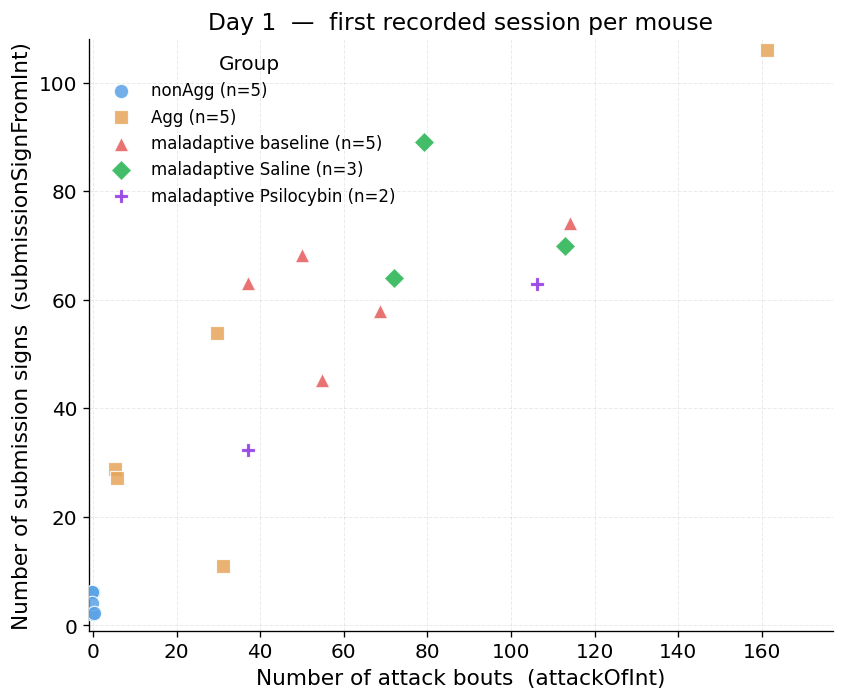

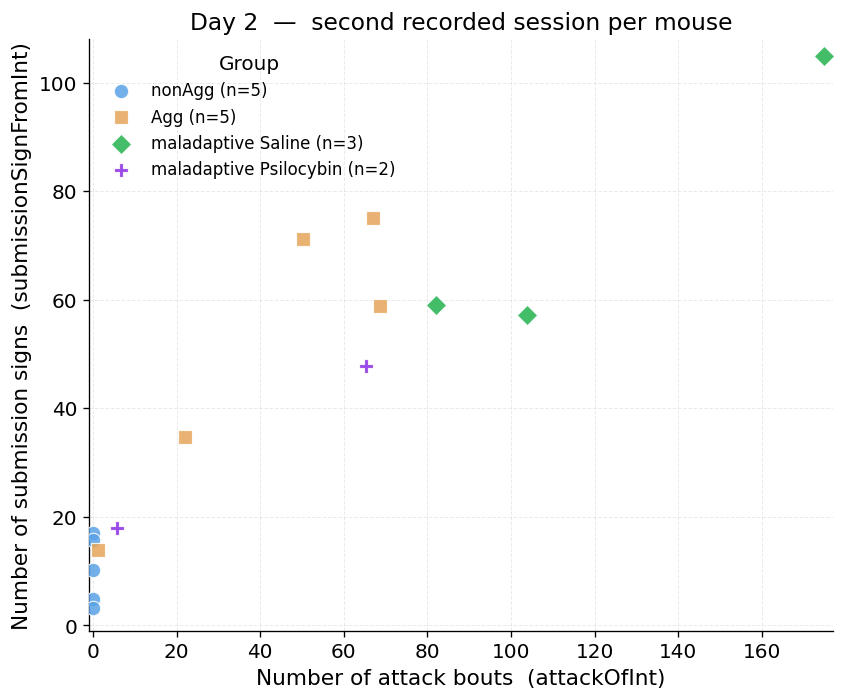

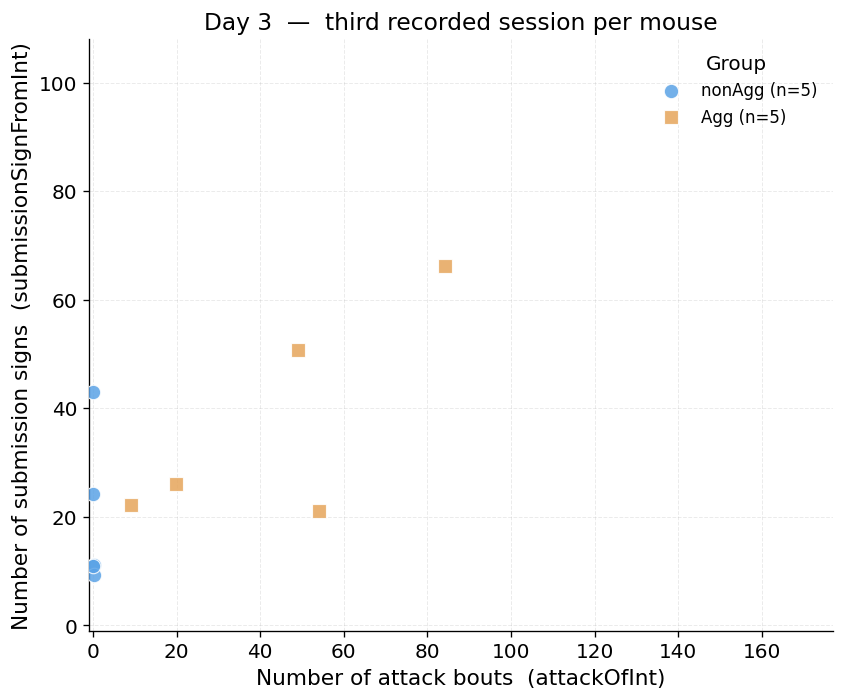

In [4]:
"""
Attack bouts (x) vs. submission signs (y), split into THREE plots:
the 1st, 2nd and 3rd recording day of each mouse within its group.

Each .annot file is a Bento export with two behaviours:
    attackOfInt            -> x axis
    submissionSignFromInt  -> y axis
A "bout"/"sign" = one (Start, Stop, Duration) row under that behaviour header.

Mouse + day are read from the "Movie file(s):" line in each file
(format  mouse<ID>_Day<NN> ), matching the filtered_results video keys.
Group assignment follows the maladaptive baseline / Saline / Psilocybin scheme.

Run:  python plot_attack_vs_submission.py
Outputs (in OUT_DIR):
    attack_vs_submission_day1.png/.pdf   (and day2, day3)
    bout_counts.csv      per-file counts + assigned group + session index
    skipped.csv          files that did not map to a group (with reason)
"""

import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------------------------------------------------------- #
# CONFIG  — edit these
# ----------------------------------------------------------------------------- #
DT_FOLDER = Path(r"A:\rawData\compressedVideos_AVI\trainingSessions_DLC"
                 r"\fig1_trainingSessions_annotationsNoemie_non_agg_mal")

OUT_DIR = Path.cwd()
N_DAYS  = 3            # number of day-plots to make (1st, 2nd, 3rd recording)
JITTER  = 0.25         # nudge identical integer counts apart (0 disables)
SHARED_AXES = True     # use the same x/y range on all day-plots for comparison

BEHAVIORS = {"attack": "attackOfInt", "submission": "submissionSignFromInt"}

# ---- mouse groups ----
Agg = ["975826", "975827", "975833", "978772", "978774", "988590",
       "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841",
          "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590",
               "1034805", "1034814"]

saline_mice = maladaptive[:3]   # 978513, 978527, 978528
psilo_mice  = maladaptive[3:]   # 1010832, 1013590, 1034805, 1034814

# ---- styling (matches your settings) ----
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive baseline": "#E65A5A",
    "maladaptive Saline": "#22B24D",
    "maladaptive Psilocybin": "#8A2BE2",
}
group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive baseline": "^",
    "maladaptive Saline": "D",
    "maladaptive Psilocybin": "P",
}
group_order = [
    "nonAgg", "Agg",
    "maladaptive baseline", "maladaptive Saline", "maladaptive Psilocybin",
]

# ----------------------------------------------------------------------------- #
# Parsing
# ----------------------------------------------------------------------------- #
_ROW_RE   = re.compile(r"^\s*\d+\s+\d+\s+\d+\s*$")      # a Start/Stop/Duration row
_VIDEO_RE = re.compile(r"mouse(\d+)_Day(\d+)")          # mouse + day, like filtered_results
_DAY_RE   = re.compile(r"[Dd]ay(\d+)")                  # fallback: day from filename


def count_bouts(annot_path: Path) -> dict:
    counts = {name: 0 for name in BEHAVIORS.values()}
    current = None
    with open(annot_path, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            s = line.strip()
            if s.startswith(">"):
                current = s[1:].strip()
            elif current in counts and _ROW_RE.match(line):
                counts[current] += 1
    return counts


def movie_basename_from(annot_path: Path):
    """Return the 'video' name (movie basename, no extension) from the file header."""
    with open(annot_path, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            if line.lower().startswith("movie file"):
                rest = line.split(":", 1)[1].strip()          # path after the label
                last = re.split(r"[\\/]", rest)[-1]           # handle \ and /
                return os.path.splitext(last)[0]
            if line.startswith("List of channels"):
                break
    return None


def extract_video_mouse_day(annot_path: Path):
    """(video, mouse, day) from the movie line; fall back to the filename."""
    video = movie_basename_from(annot_path)
    if video:
        m = _VIDEO_RE.match(video) or _VIDEO_RE.search(video)
        if m:
            return video, m.group(1), int(m.group(2))
    # fallback: filename
    stem = annot_path.stem
    md = _DAY_RE.search(stem)
    mid = next((p.group(1) for p in [re.search(rf"(?<!\d){i}(?!\d)", stem)
                                     for i in (Agg + nonAgg + maladaptive)] if p), None)
    if md and mid:
        return stem, mid, int(md.group(1))
    return video or stem, None, None


def assign_group(mouse, day):
    """Returns (group, skip_reason). Mirrors the resultsDataset logic."""
    if mouse in Agg:
        return "Agg", None
    if mouse in nonAgg:
        return "nonAgg", None
    if mouse in maladaptive and day is not None and day <= 5:
        return "maladaptive baseline", None
    if mouse in psilo_mice and day is not None and day >= 15:
        return "maladaptive Psilocybin", None
    if mouse in saline_mice and day is not None and day >= 15:
        return "maladaptive Saline", None
    return None, "mouse_not_in_group_lists"


def collect():
    if not DT_FOLDER.exists():
        sys.exit(f"DT_FOLDER does not exist:\n  {DT_FOLDER}")
    files = sorted(DT_FOLDER.rglob("*.annot"))
    if not files:
        sys.exit(f"No .annot files found under:\n  {DT_FOLDER}")

    rows, skipped = [], []
    for f in files:
        video, mouse, day = extract_video_mouse_day(f)
        if mouse is None or day is None:
            skipped.append({"file": f.name, "video": video, "reason": "regex_no_match"})
            continue
        group, reason = assign_group(mouse, day)
        if group is None:
            skipped.append({"file": f.name, "video": video, "mouse": mouse,
                            "day": day, "reason": reason})
            continue
        c = count_bouts(f)
        rows.append({
            "video": video, "mouse": mouse, "mouse_group_id": f"{mouse}_{group}",
            "day": day, "group": group,
            "attack_bouts": c[BEHAVIORS["attack"]],
            "submission_signs": c[BEHAVIORS["submission"]],
        })

    df = pd.DataFrame(rows)
    skipped_df = pd.DataFrame(skipped)
    if df.empty:
        if not skipped_df.empty:
            print(skipped_df.to_string(index=False))
        sys.exit("No .annot files mapped to a group.")

    # session index = 1st / 2nd / 3rd recording day per mouse WITHIN its group
    df = df.sort_values(["group", "mouse", "day"]).reset_index(drop=True)
    df["session_idx"] = df.groupby(["mouse", "group"]).cumcount() + 1
    return df, skipped_df


# ----------------------------------------------------------------------------- #
# Plotting
# ----------------------------------------------------------------------------- #
def style():
    mpl.rcParams.update({
        "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13,
        "axes.spines.top": False, "axes.spines.right": False,
        "figure.dpi": 120, "savefig.dpi": 300,
    })


def plot_day(df_day, day_idx, xlim, ylim, rng):
    fig, ax = plt.subplots(figsize=(7.2, 6))
    for g in group_order:
        sub = df_day[df_day["group"] == g]
        if sub.empty:
            continue
        x = sub["attack_bouts"].to_numpy(float)
        y = sub["submission_signs"].to_numpy(float)
        if JITTER:
            x = x + rng.uniform(-JITTER, JITTER, x.shape)
            y = y + rng.uniform(-JITTER, JITTER, y.shape)
        ax.scatter(x, y, s=75, c=group_colors[g], marker=group_markers[g], alpha=0.85,
                   edgecolors="white", linewidths=0.7,
                   label=f"{g} (n={len(sub)})", zorder=3)
    ordinal = {1: "first", 2: "second", 3: "third"}.get(day_idx, f"{day_idx}th")
    ax.set_xlabel("Number of attack bouts  (attackOfInt)")
    ax.set_ylabel("Number of submission signs  (submissionSignFromInt)")
    ax.set_title(f"Day {day_idx}  —  {ordinal} recorded session per mouse")
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)
    ax.legend(title="Group", frameon=False, loc="best", fontsize=10)
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
    fig.tight_layout()
    return fig


def main():
    style()
    df, skipped_df = collect()

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    df.sort_values(["group", "mouse", "day"]).to_csv(OUT_DIR / "bout_counts.csv", index=False)
    if not skipped_df.empty:
        skipped_df.to_csv(OUT_DIR / "skipped.csv", index=False)

    xlim = ylim = None
    if SHARED_AXES:
        xlim = (-1, df["attack_bouts"].max() + 2)
        ylim = (-1, df["submission_signs"].max() + 2)

    rng = np.random.default_rng(0)
    made = []
    for k in range(1, N_DAYS + 1):
        df_k = df[df["session_idx"] == k]
        if df_k.empty:
            print(f"  [note] no recordings for day {k}; skipping figure.")
            continue
        fig = plot_day(df_k, k, xlim, ylim, rng)
        png = OUT_DIR / f"attack_vs_submission_day{k}.png"
        pdf = OUT_DIR / f"attack_vs_submission_day{k}.pdf"
        fig.savefig(png, bbox_inches="tight")
        fig.savefig(pdf, bbox_inches="tight")
        made.append(png)

    print(f"\nParsed {len(df)} recordings from {df['mouse'].nunique()} mice.")
    print(df.groupby(["group", "session_idx"]).size().to_string())
    if not skipped_df.empty:
        print(f"\nSkipped {len(skipped_df)} file(s) -> skipped.csv")
    print("\nSaved figures:")
    for p in made:
        print(f"  {p}")
    plt.show()


if __name__ == "__main__":
    main()